In [1]:
import tensorflow as tf
print(tf.__version__)  # Should output "2.10.0"

2.10.0


In [2]:
import sklearn
print(sklearn.__version__)  # Should print the version (e.g., 1.2.2)

1.3.0


In [5]:
import matplotlib
print(matplotlib.__version__)  # Should print the version (e.g., 3.7.1)

3.7.5


In [7]:
!pip install numpy pandas opencv-python tensorflow scikit-learn matplotlib

Found 1600 images belonging to 10 classes.
Found 400 images belonging to 10 classes.
Epoch 1/50
50/50 [==============================] - 56s 1s/step - loss: 1.6068 - accuracy: 0.4806 - val_loss: 3.6113 - val_accuracy: 0.1901 - lr: 0.0010
Epoch 2/50
50/50 [==============================] - 34s 687ms/step - loss: 0.6105 - accuracy: 0.7962 - val_loss: 5.1502 - val_accuracy: 0.1068 - lr: 0.0010
Epoch 3/50
50/50 [==============================] - 33s 656ms/step - loss: 0.3716 - accuracy: 0.8831 - val_loss: 5.0950 - val_accuracy: 0.1120 - lr: 0.0010
Epoch 4/50
50/50 [==============================] - 37s 747ms/step - loss: 0.1904 - accuracy: 0.9469 - val_loss: 5.1688 - val_accuracy: 0.1042 - lr: 0.0010
Epoch 5/50
50/50 [==============================] - 36s 718ms/step - loss: 0.1045 - accuracy: 0.9731 - val_loss: 5.4320 - val_accuracy: 0.1094 - lr: 0.0010
Epoch 6/50
50/50 [==============================] - 35s 703ms/step - loss: 0.0675 - accuracy: 0.9844 - val_loss: 7.3415 - val_accuracy: 0.

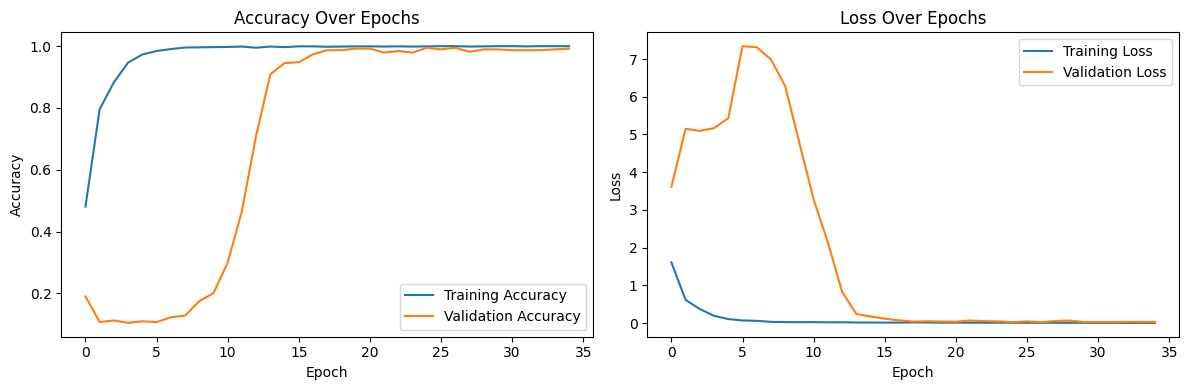

13/13 [==============================] - 5s 373ms/step
Classification Report:
               precision    recall  f1-score   support

      01_palm       1.00      0.95      0.97        40
         02_l       1.00      1.00      1.00        40
      03_fist       0.95      1.00      0.98        40
04_fist_moved       1.00      1.00      1.00        40
     05_thumb       1.00      1.00      1.00        40
     06_index       1.00      1.00      1.00        40
        07_ok       0.95      1.00      0.98        40
08_palm_moved       1.00      1.00      1.00        40
         09_c       1.00      1.00      1.00        40
      10_down       1.00      0.95      0.97        40

     accuracy                           0.99       400
    macro avg       0.99      0.99      0.99       400
 weighted avg       0.99      0.99      0.99       400


Confusion Matrix:
[[38  0  2  0  0  0  0  0  0  0]
 [ 0 40  0  0  0  0  0  0  0  0]
 [ 0  0 40  0  0  0  0  0  0  0]
 [ 0  0  0 40  0  0  0  0  0  0

In [9]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Dataset parameters
DATASET_PATH = r"C:\Users\Mohammad Rihan\Downloads\leapGestRecog"  # Update with your actual path
IMG_SIZE = (128, 128)  # Reduced size for faster training
BATCH_SIZE = 32
NUM_CLASSES = 10

# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    validation_split=0.2,
    fill_mode='nearest'
)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    color_mode='rgb',
    shuffle=True
)

# Validation data generator
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb',
    shuffle=False
)

# Model architecture
def create_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        BatchNormalization(),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create and compile model
model = create_model((IMG_SIZE[0], IMG_SIZE[1], 3), NUM_CLASSES)
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# Training
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=50,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluation
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Generate predictions
val_generator.reset()
y_pred = model.predict(val_generator, steps=val_generator.samples // BATCH_SIZE + 1)
y_pred = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

# Classification report
class_names = list(train_generator.class_indices.keys())
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Save the model
model.save('hand_gesture_recognition.h5')
print("Model saved as hand_gesture_recognition.h5")

# For real-time prediction (example function)
def predict_gesture(image_path, model):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch axis
    img_array /= 255.0
    
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])
    
    return predicted_class, confidence